
Checking for actual World Cup knockout results to update Poisson Model...

--- Round of 32 ---
OK R32: Germany vs Paraguay -> Paraguay (1-1 from database)
OK R32: France vs Sweden -> France (3-0 from database)
OK R32: South Africa vs Canada -> Canada (0-1 from database)
OK R32: Netherlands vs Morocco -> Morocco (1-1 from database)
OK R32: Portugal vs Croatia -> Portugal (2-1 from database)
OK R32: Spain vs Austria -> Spain (3-0 from database)
OK R32: United States vs Bosnia and Herzegovina -> United States (2-0 from database)
OK R32: Belgium vs Senegal -> Belgium (3-2 from database)
OK R32: Brazil vs Japan -> Brazil (2-1 from database)
OK R32: Ivory Coast vs Norway -> Norway (1-2 from database)
OK R32: Mexico vs Ecuador -> Mexico (2-0 from database)
OK R32: England vs DR Congo -> England (2-1 from database)
OK R32: Argentina vs Cape Verde -> Argentina (3-2 from database)
OK R32: Australia vs Egypt -> Egypt (1-1 from database)
OK R32: Switzerland vs Algeria -> Switzerland (2-0 from dat

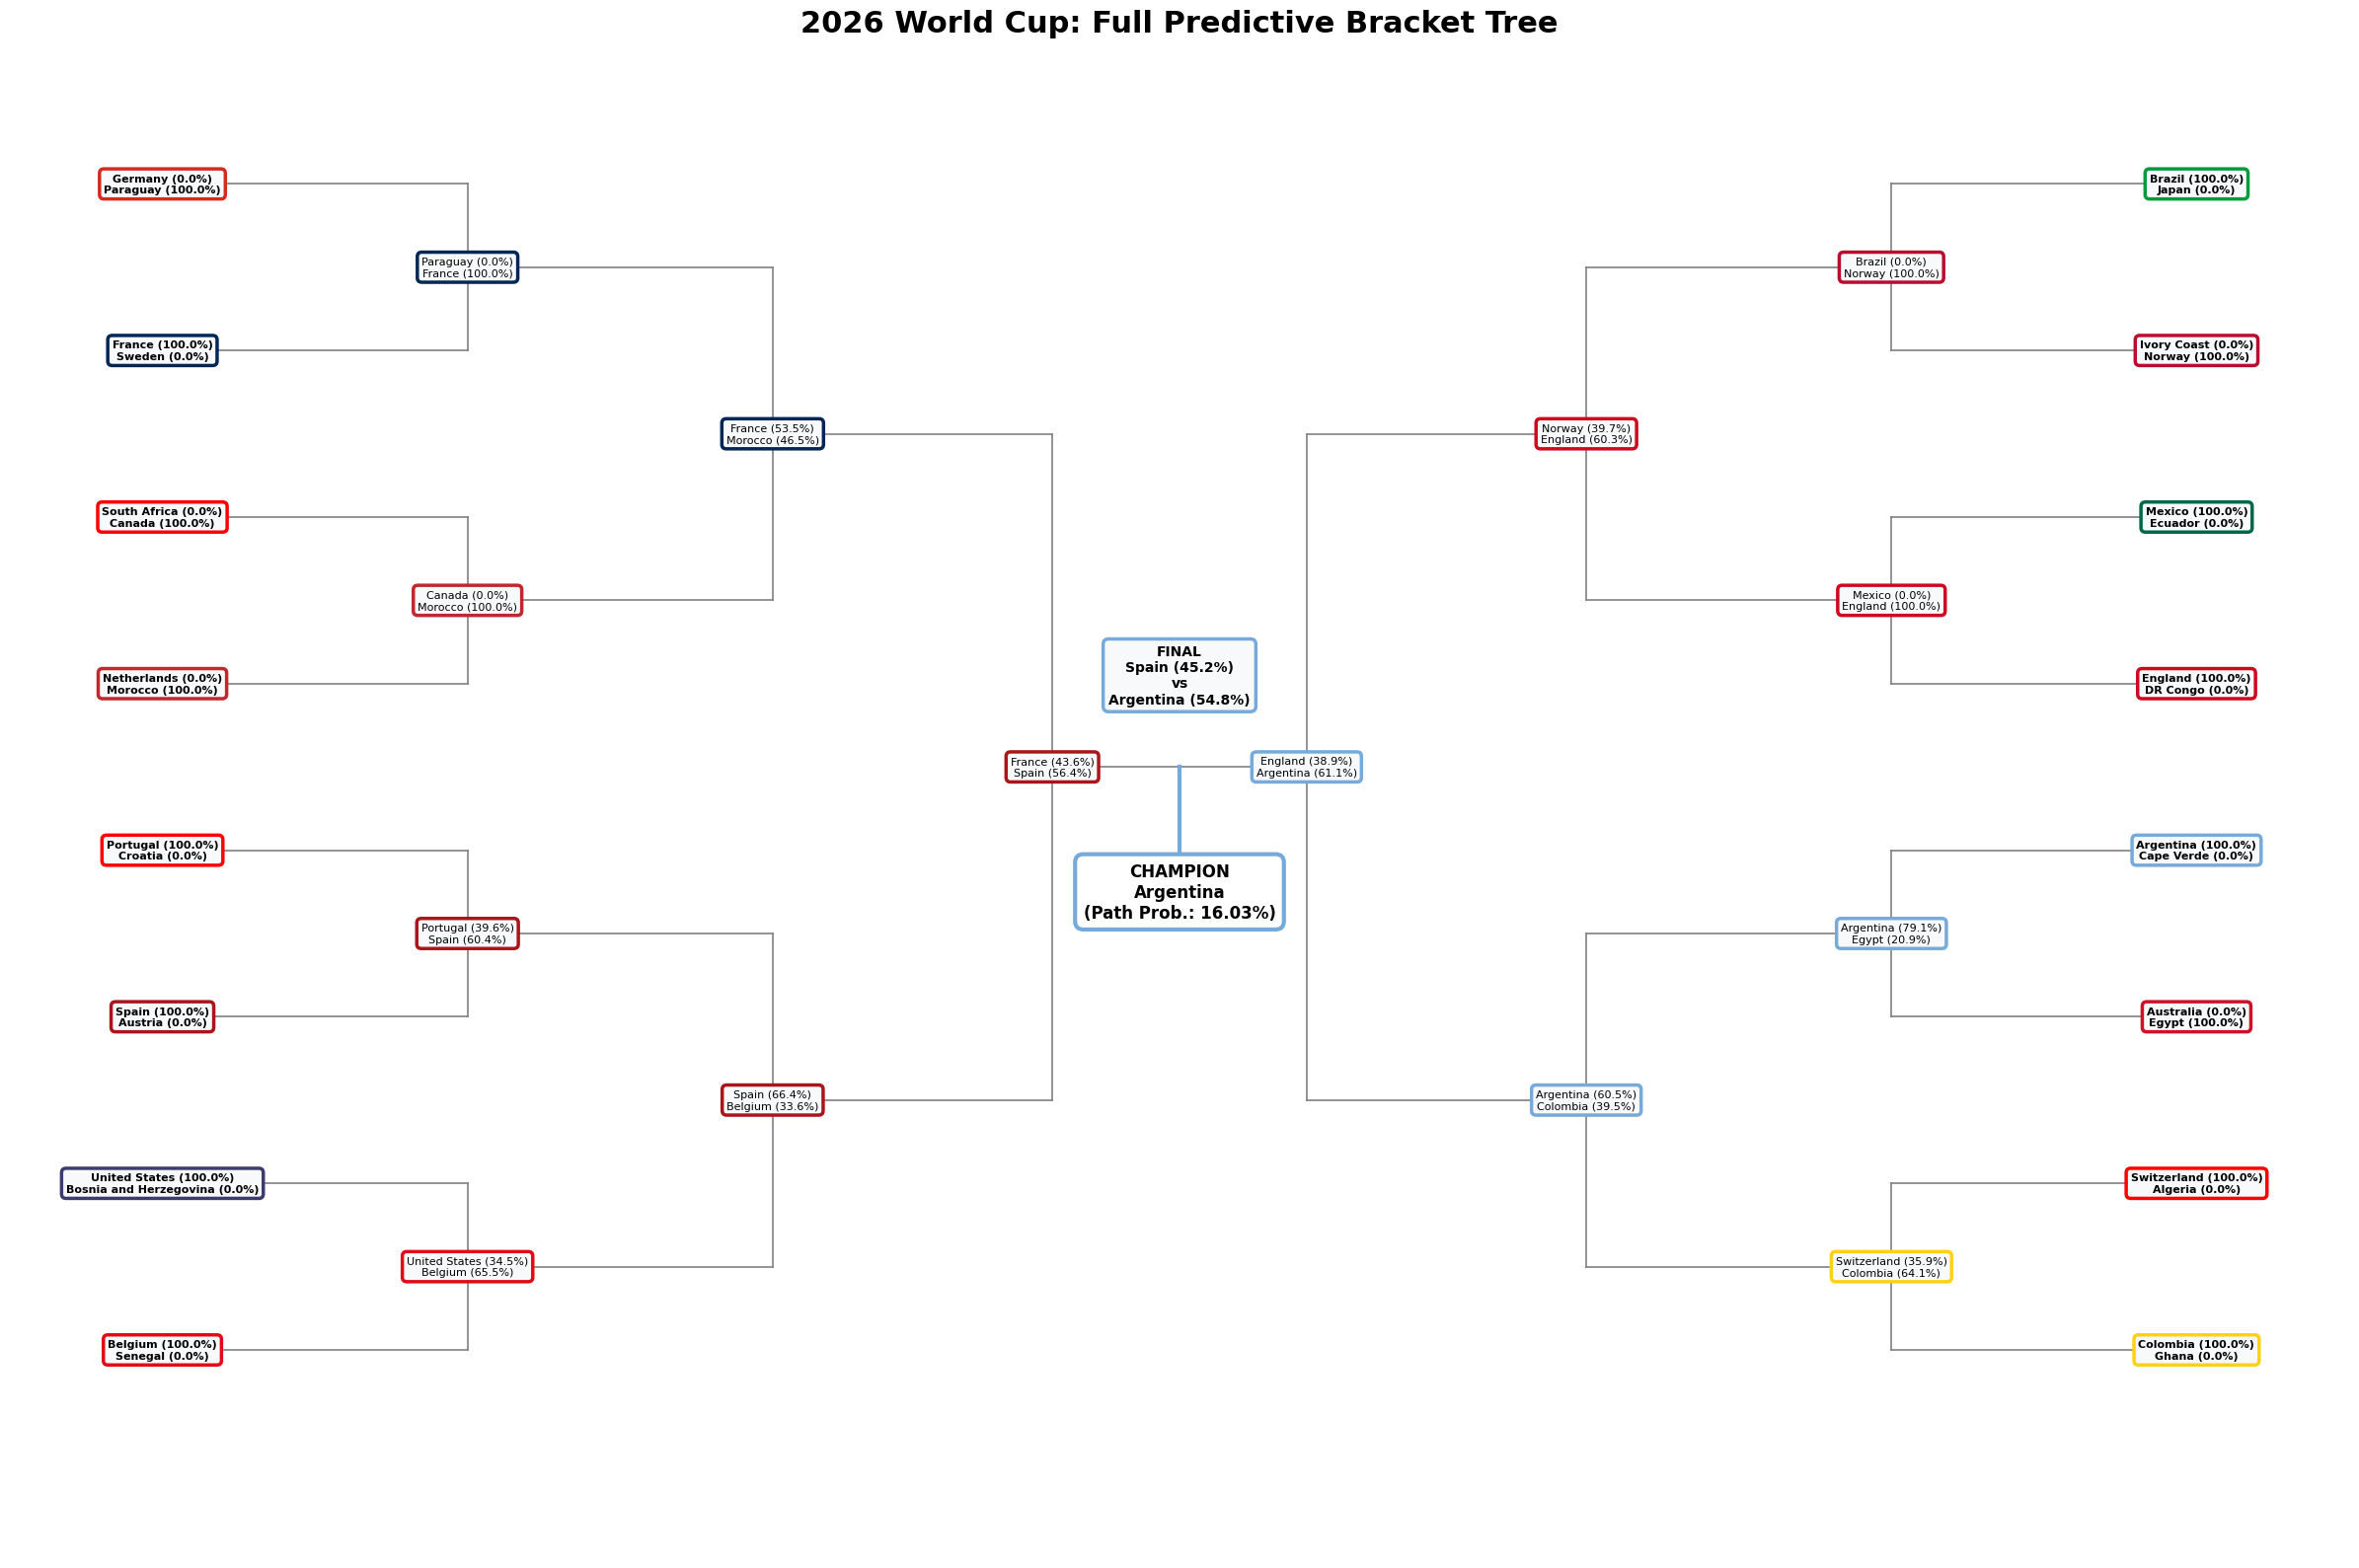

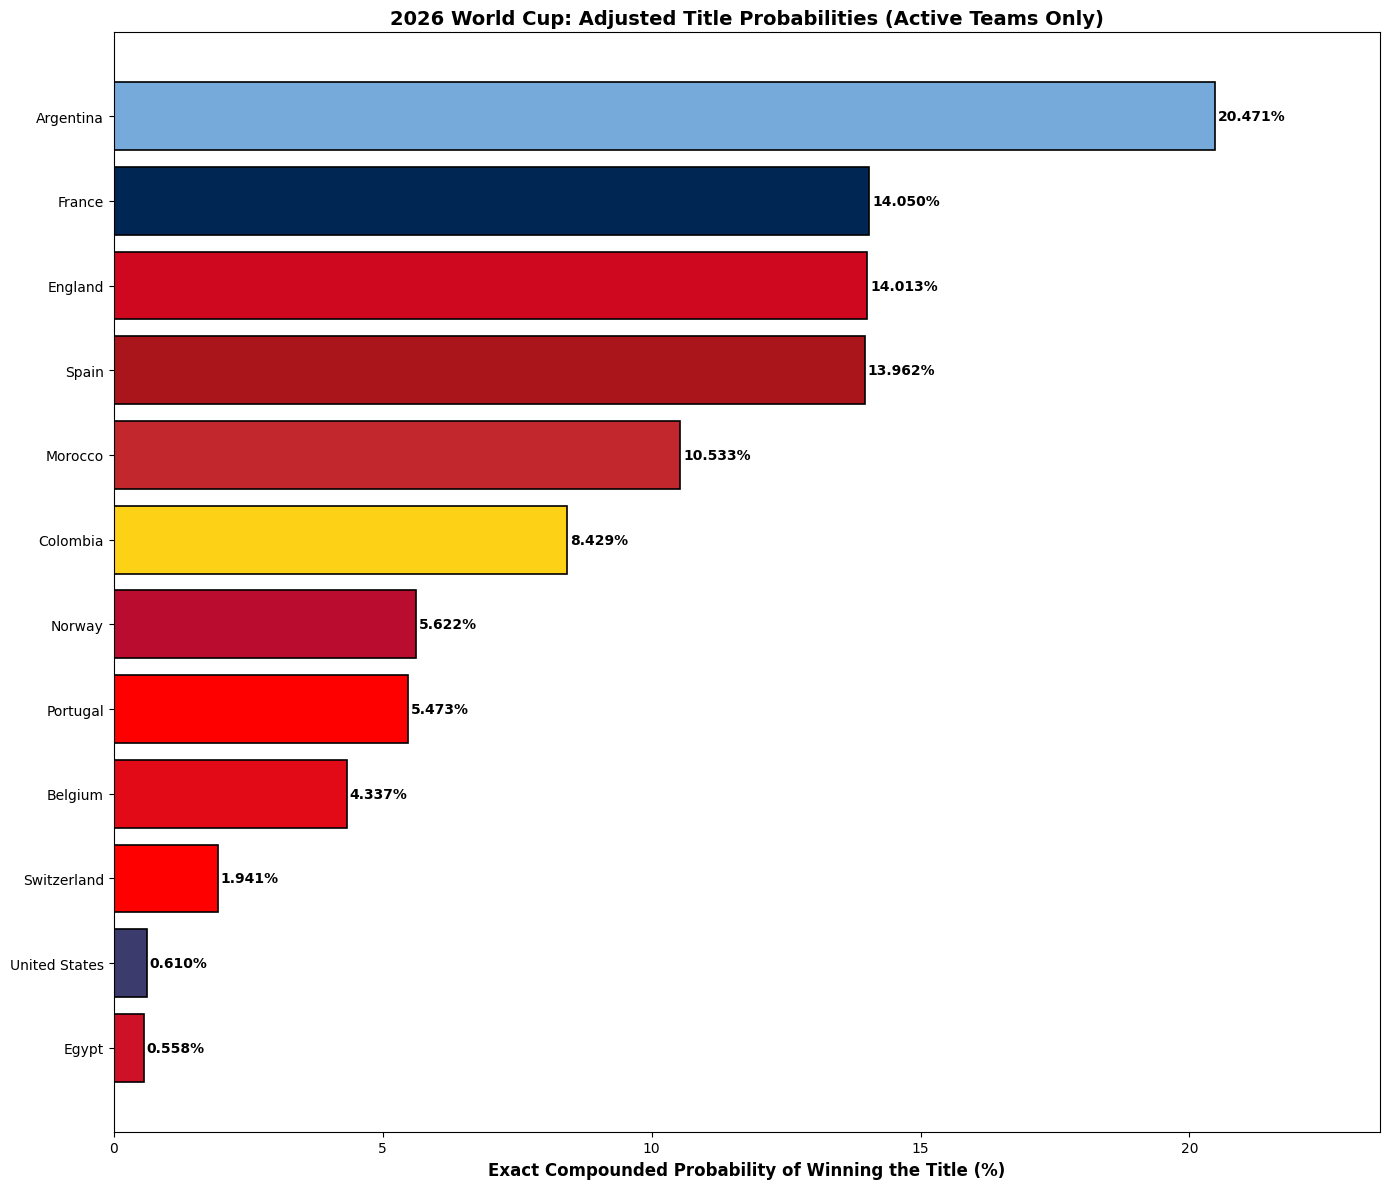

Probabilities exported to /home/daves/google_drive/Pessoal/Notebooks/2026 World Cup/2026_wc_adjusted_title_probabilities_06_07.csv


In [1]:
# ==============================================================================
# ENVIRONMENT SETUP & OPTIMIZATION BLOCK
# ==============================================================================
import os, jax, logging, pymc.sampling.jax

os.environ.update({
    "OMP_NUM_THREADS": "1",
    "OPENBLAS_NUM_THREADS": "1",
    "MKL_NUM_THREADS": "1",
    "VECLIB_MAXIMUM_THREADS": "1",
    "NUMEXPR_NUM_THREADS": "1",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "false",
    "XLA_PYTHON_CLIENT_ALLOCATOR": "platform"
})
logging.getLogger("pymc").setLevel(logging.ERROR)
jax.config.update("jax_platform_name", "cuda")

# ==============================================================================
# IMPORTS AND DATA PIPELINE
# ==============================================================================
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

work_dir = "/home/daves/google_drive/Pessoal/Notebooks/2026 World Cup"
os.makedirs(work_dir, exist_ok=True)

print("Downloading historical data (Post-2022 World Cup Final)...")
url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'] > '2022-12-18'].copy()
df = df.dropna(subset=['home_score', 'away_score'])
df['home_score'] = df['home_score'].astype(int)
df['away_score'] = df['away_score'].astype(int)
df['is_neutral'] = df['neutral'].astype(int)

# ------------------------------------------------------------------------------
# INJECT NEW MATCH DATA (HARDCODED)
# ------------------------------------------------------------------------------
novos_jogos = pd.DataFrame({
    'date': ['2026-07-01', '2026-07-01'],
    'home_team': ['Brazil', 'Germany'],
    'away_team': ['Argentina', 'France'],
    'home_score': [2, 1],
    'away_score': [1, 0],
    'tournament': ['FIFA World Cup', 'FIFA World Cup'],
    'neutral': [True, True]
})
novos_jogos['date'] = pd.to_datetime(novos_jogos['date'])
novos_jogos['is_neutral'] = novos_jogos['neutral'].astype(int)
df = pd.concat([df, novos_jogos], ignore_index=True)

# ==============================================================================
# BRACKET DEFINITION AND COLORS
# ==============================================================================
ordered_bracket_teams = [
    "Germany", "Paraguay", "France", "Sweden",
    "South Africa", "Canada", "Netherlands", "Morocco",
    "Portugal", "Croatia", "Spain", "Austria",
    "United States", "Bosnia and Herzegovina", "Belgium", "Senegal",
    "Brazil", "Japan", "Ivory Coast", "Norway",
    "Mexico", "Ecuador", "England", "DR Congo",
    "Argentina", "Cape Verde", "Australia", "Egypt",
    "Switzerland", "Algeria", "Colombia", "Ghana"
]

team_colors = {
    "Germany": "#000000", "Paraguay": "#D52B1E", "France": "#002654", "Sweden": "#FECC00",
    "South Africa": "#007749", "Canada": "#FF0000", "Netherlands": "#F36C21", "Morocco": "#C1272D",
    "Portugal": "#FF0000", "Croatia": "#FF0000", "Spain": "#AA151B", "Austria": "#ED2939",
    "United States": "#3C3B6E", "Bosnia and Herzegovina": "#002395", "Belgium": "#E30A17", "Senegal": "#00853F",
    "Brazil": "#009B3A", "Japan": "#BC002D", "Ivory Coast": "#F77F00", "Norway": "#BA0C2F",
    "Mexico": "#006847", "Ecuador": "#FFDD00", "England": "#CF081F", "DR Congo": "#007FFF",
    "Argentina": "#75AADB", "Cape Verde": "#003893", "Australia": "#00008B", "Egypt": "#CE1126",
    "Switzerland": "#FF0000", "Algeria": "#006233", "Colombia": "#FCD116", "Ghana": "#006B3F"
}

# ==============================================================================
# DYNAMIC MATCH RESULT INJECTION (PROMPTING BEFORE POISSON MODEL)
# ==============================================================================
print("\nChecking for actual World Cup knockout results to update Poisson Model...")

WORLD_CUP_START = pd.Timestamp("2026-06-11")
df_wc = df[(df['tournament'] == "FIFA World Cup") & (df['date'] >= WORLD_CUP_START)].copy()

known_knockout = {}
new_matches = []

def process_match(tA, tB, stage_name):
    key = tuple(sorted([tA, tB]))
    mask = ((df_wc['home_team'] == tA) & (df_wc['away_team'] == tB)) | \
           ((df_wc['home_team'] == tB) & (df_wc['away_team'] == tA))
    match = df_wc[mask]

    # 1. Match exists in our dataframe (either from CSV or novos_jogos)
    if len(match) > 0:
        row = match.iloc[-1]
        h_team, a_team = row['home_team'], row['away_team']
        h_score, a_score = int(row['home_score']), int(row['away_score'])
        if h_score > a_score:
            winner = h_team
        elif a_score > h_score:
            winner = a_team
        else:
            winner = input(f"[{stage_name}] {tA} vs {tB} found as draw ({h_score}-{a_score}). Who advanced? ({tA} or {tB}): ").strip()
        print(f"OK {stage_name}: {tA} vs {tB} -> {winner} ({h_score}-{a_score} from database)")
        known_knockout[key] = winner
        return winner

    # 2. Prompt user for scores to update the Poisson model with unseen data
    ans = input(f"[{stage_name}] Enter score for {tA} vs {tB} (format '2-1', or Enter to skip): ").strip()

    if not ans:
        print(f"   -> Not yet played or skipped.")
        return None

    parts = ans.split('-')
    valid_format = len(parts) == 2 and all(p.strip().lstrip('-').isdigit() for p in parts)

    if not valid_format:
        print(f"   -> Invalid format. Skipping match.")
        return None

    sa, sb = int(parts[0]), int(parts[1])
    if sa > sb:
        winner = tA
    elif sb > sa:
        winner = tB
    else:
        winner = input(f"   -> Match drawn. Who advanced? ({tA} or {tB}): ").strip()

    new_matches.append({
        'date': pd.Timestamp.today().strftime('%Y-%m-%d'),
        'home_team': tA,
        'away_team': tB,
        'home_score': sa,
        'away_score': sb,
        'tournament': 'FIFA World Cup',
        'neutral': True,
        'is_neutral': 1
    })
    known_knockout[key] = winner
    print(f"   -> Logged manually: {tA} {sa}-{sb} {tB} | Winner: {winner}")
    return winner

# Traverse Bracket dynamically
print("\n--- Round of 32 ---")
r32_winners = []
for i in range(0, 32, 2):
    w = process_match(ordered_bracket_teams[i], ordered_bracket_teams[i + 1], "R32")
    r32_winners.append(w)

print("\n--- Round of 16 ---")
r16_winners = []
for i in range(0, 16, 2):
    w = process_match(r32_winners[i], r32_winners[i + 1], "R16") if r32_winners[i] and r32_winners[i + 1] else None
    r16_winners.append(w)

print("\n--- Quarter-finals ---")
qf_winners = []
for i in range(0, 8, 2):
    w = process_match(r16_winners[i], r16_winners[i + 1], "QF") if r16_winners[i] and r16_winners[i + 1] else None
    qf_winners.append(w)

print("\n--- Semi-finals ---")
sf_winners = []
for i in range(0, 4, 2):
    w = process_match(qf_winners[i], qf_winners[i + 1], "SF") if qf_winners[i] and qf_winners[i + 1] else None
    sf_winners.append(w)

print("\n--- Final ---")
if sf_winners[0] and sf_winners[1]:
    final_winner = process_match(sf_winners[0], sf_winners[1], "FINAL")

# Append newly logged matches to main df to update Poisson parameters
if new_matches:
    df_new = pd.DataFrame(new_matches)
    df_new['date'] = pd.to_datetime(df_new['date'])
    df = pd.concat([df, df_new], ignore_index=True)
    print(f"\nAppended {len(new_matches)} new inputted matches to training data.")

# ==============================================================================
# PYMC MCMC INFERENCE MODEL (BLACKJAX NUTS ON GPU)
# ==============================================================================
print("\nCompiling MCMC Graph and Initializing BlackJAX NUTS Sampler...")

# Data mapping must happen AFTER appending all new match inputs
teams_global = pd.unique(df[['home_team', 'away_team']].values.ravel())
n_teams_global = len(teams_global)
team_to_idx_global = {team: i for i, team in enumerate(teams_global)}
idx_to_team_global = {i: team for i, team in enumerate(teams_global)}

home_idx = df['home_team'].map(team_to_idx_global).values
away_idx = df['away_team'].map(team_to_idx_global).values
home_goals = df['home_score'].values
away_goals = df['away_score'].values
home_adv_mask = (1 - df['is_neutral'].values)

with pm.Model() as wc_model:
    baseline = pm.Normal("baseline", mu=0, sigma=1)
    home_adv = pm.Normal("home_adv", mu=0.2, sigma=0.5)
    attack_raw = pm.Normal("attack_raw", mu=0, sigma=1, shape=n_teams_global)
    defense_raw = pm.Normal("defense_raw", mu=0, sigma=1, shape=n_teams_global)
    attack = pm.Deterministic("attack", attack_raw - pm.math.mean(attack_raw))
    defense = pm.Deterministic("defense", defense_raw - pm.math.mean(defense_raw))
    theta_home = pm.math.exp(baseline + home_adv * home_adv_mask + attack[home_idx] - defense[away_idx])
    theta_away = pm.math.exp(baseline + attack[away_idx] - defense[home_idx])
    home_obs = pm.Poisson("home_obs", mu=theta_home, observed=home_goals)
    away_obs = pm.Poisson("away_obs", mu=theta_away, observed=away_goals)

    idata = pymc.sampling.jax.sample_blackjax_nuts(
        draws=5000, tune=5000, chains=4, chain_method="vectorized", progressbar=False, random_seed=42
    )

posterior_attack = idata.posterior["attack"].mean(dim=["chain", "draw"]).values
posterior_defense = idata.posterior["defense"].mean(dim=["chain", "draw"]).values
global_baseline = float(idata.posterior["baseline"].mean())

inferred_fa = np.exp(posterior_attack)
inferred_fd = np.exp(-posterior_defense)
team_metrics = {idx_to_team_global[i]: {"FA": inferred_fa[i], "FD": inferred_fd[i]} for i in range(n_teams_global)}

# ==============================================================================
# BASE PROBABILITY MATRIX (OPTIMIZED: UPPER TRIANGLE ONLY, 20000 SIMULATIONS)
# ==============================================================================
print("\nBuilding 32x32 Win Probability Matrix...")

def get_host_advantage(team_name):
    if team_name == "United States":
        return 1 + (0.10 * (np.log(333000000) / np.log(333000000)))
    if team_name == "Mexico":
        return 1 + (0.10 * (np.log(128000000) / np.log(333000000)))
    if team_name == "Canada":
        return 1 + (0.10 * (np.log(39000000) / np.log(333000000)))
    return 1.0

win_prob_matrix = np.zeros((32, 32))
N_SIMULATIONS = 100000

for i in range(32):
    for j in range(i + 1, 32):
        team_a, team_b = ordered_bracket_teams[i], ordered_bracket_teams[j]
        fa_a, fd_a = team_metrics.get(team_a, {"FA": 1.0, "FD": 1.0}).values()
        fa_b, fd_b = team_metrics.get(team_b, {"FA": 1.0, "FD": 1.0}).values()

        lambda_a = np.exp(global_baseline) * fa_a * fd_b * get_host_advantage(team_a)
        lambda_b = np.exp(global_baseline) * fa_b * fd_a * get_host_advantage(team_b)

        goals_a = np.random.poisson(lambda_a, N_SIMULATIONS)
        goals_b = np.random.poisson(lambda_b, N_SIMULATIONS)
        wins_a = np.sum(goals_a > goals_b)
        draws = np.sum(goals_a == goals_b)
        pens_a = np.sum(np.random.binomial(1, 0.5, draws))

        prob_a = (wins_a + pens_a) / N_SIMULATIONS
        win_prob_matrix[i, j] = prob_a
        win_prob_matrix[j, i] = 1.0 - prob_a

# Apply all known knockout results to win probability matrix
print("\nApplying known results to probability matrix bounds...")
eliminated_teams_list = []
for (t1, t2), winner in known_knockout.items():
    loser = t1 if winner == t2 else t2
    eliminated_teams_list.append(loser)
    if t1 in ordered_bracket_teams and t2 in ordered_bracket_teams:
        i = ordered_bracket_teams.index(t1)
        j = ordered_bracket_teams.index(t2)
        if winner == t1:
            win_prob_matrix[i, j] = 1.0
            win_prob_matrix[j, i] = 0.0
        else:
            win_prob_matrix[i, j] = 0.0
            win_prob_matrix[j, i] = 1.0

# ==============================================================================
# ALGORITHM 1: EXACT MARKOV CHAIN MULTIPLICATION (ALL PATHS)
# ==============================================================================
print("Calculating Exact Compounded Title Probabilities...")
bracket_stage_probs = np.zeros((6, 32))
bracket_stage_probs[0, :] = 1.0

for stage in range(1, 6):
    group_size = 2 ** stage
    half_group = group_size // 2
    for i in range(32):
        group_start = (i // group_size) * group_size
        is_first_half = (i - group_start) < half_group
        opp_start = group_start + half_group if is_first_half else group_start
        opp_end = opp_start + half_group

        prob_beat_opponent = sum(
            bracket_stage_probs[stage - 1, k] * win_prob_matrix[i, k]
            for k in range(opp_start, opp_end)
        )
        bracket_stage_probs[stage, i] = bracket_stage_probs[stage - 1, i] * prob_beat_opponent

exact_title_probs = {ordered_bracket_teams[i]: bracket_stage_probs[5, i] for i in range(32)}

# ==============================================================================
# ALGORITHM 2: DETERMINISTIC MOST PROBABLE PATH (TREE)
# ==============================================================================
bracket_phases = {"round_of_32": [], "round_of_16": [], "quarterfinals": [], "semifinals": [], "final": []}
tree_path_probs = {team: 1.0 for team in ordered_bracket_teams}
current_teams = list(range(32))
phase_names = ["round_of_32", "round_of_16", "quarterfinals", "semifinals", "final"]

for phase_idx, phase_name in enumerate(phase_names):
    next_teams = []
    for i in range(0, len(current_teams), 2):
        idx_a, idx_b = current_teams[i], current_teams[i + 1]
        team_a, team_b = ordered_bracket_teams[idx_a], ordered_bracket_teams[idx_b]
        p_a, p_b = win_prob_matrix[idx_a, idx_b], 1.0 - win_prob_matrix[idx_a, idx_b]

        tree_path_probs[team_a] *= p_a
        tree_path_probs[team_b] *= p_b

        winner_idx = idx_a if p_a > p_b else idx_b
        winner_name = ordered_bracket_teams[winner_idx]
        next_teams.append(winner_idx)

        bracket_phases[phase_name].append({
            "team_a": team_a, "prob_a": p_a,
            "team_b": team_b, "prob_b": p_b,
            "winner": winner_name
        })
    current_teams = next_teams

tree_champion = bracket_phases["final"][0]["winner"]

# ==============================================================================
# PLOT 1: COLORED PREDICTIVE BRACKET TREE
# ==============================================================================
fig1, ax1 = plt.subplots(figsize=(24, 16))
ax1.set_facecolor('#ffffff')
ax1.axis('off')

match_coords = {}

def get_box_style(winner_team):
    color = team_colors.get(winner_team, "#ced4da")
    return dict(boxstyle="round,pad=0.4", fc="#f8f9fa", ec=color, lw=2.5)

for i, m in enumerate(bracket_phases["round_of_32"]):
    x = 0 if i < 8 else 8
    y = 14 - 2 * i if i < 8 else 14 - 2 * (i - 8)
    match_coords[("round_of_32", i)] = (x, y)
    text = f"{m['team_a']} ({m['prob_a']*100:.1f}%)\n{m['team_b']} ({m['prob_b']*100:.1f}%)"
    ax1.text(x, y, text, ha='center', va='center', fontsize=8, bbox=get_box_style(m['winner']), fontweight='bold', zorder=3)

for i, m in enumerate(bracket_phases["round_of_16"]):
    x = 1.2 if i < 4 else 6.8
    p1, p2 = match_coords[("round_of_32", 2 * i)], match_coords[("round_of_32", 2 * i + 1)]
    y = (p1[1] + p2[1]) / 2
    match_coords[("round_of_16", i)] = (x, y)
    ax1.plot([p1[0], x], [p1[1], p1[1]], color='gray', lw=1.2, zorder=1)
    ax1.plot([p2[0], x], [p2[1], p2[1]], color='gray', lw=1.2, zorder=1)
    ax1.plot([x, x], [p1[1], p2[1]], color='gray', lw=1.2, zorder=1)
    text = f"{m['team_a']} ({m['prob_a']*100:.1f}%)\n{m['team_b']} ({m['prob_b']*100:.1f}%)"
    ax1.text(x, y, text, ha='center', va='center', fontsize=8, bbox=get_box_style(m['winner']), zorder=3)

for i, m in enumerate(bracket_phases["quarterfinals"]):
    x = 2.4 if i < 2 else 5.6
    p1, p2 = match_coords[("round_of_16", 2 * i)], match_coords[("round_of_16", 2 * i + 1)]
    y = (p1[1] + p2[1]) / 2
    match_coords[("quarterfinals", i)] = (x, y)
    ax1.plot([p1[0], x], [p1[1], p1[1]], color='gray', lw=1.2, zorder=1)
    ax1.plot([p2[0], x], [p2[1], p2[1]], color='gray', lw=1.2, zorder=1)
    ax1.plot([x, x], [p1[1], p2[1]], color='gray', lw=1.2, zorder=1)
    text = f"{m['team_a']} ({m['prob_a']*100:.1f}%)\n{m['team_b']} ({m['prob_b']*100:.1f}%)"
    ax1.text(x, y, text, ha='center', va='center', fontsize=8, bbox=get_box_style(m['winner']), zorder=3)

for i, m in enumerate(bracket_phases["semifinals"]):
    x = 3.5 if i == 0 else 4.5
    p1, p2 = match_coords[("quarterfinals", 2 * i)], match_coords[("quarterfinals", 2 * i + 1)]
    y = (p1[1] + p2[1]) / 2
    match_coords[("semifinals", i)] = (x, y)
    ax1.plot([p1[0], x], [p1[1], p1[1]], color='gray', lw=1.2, zorder=1)
    ax1.plot([p2[0], x], [p2[1], p2[1]], color='gray', lw=1.2, zorder=1)
    ax1.plot([x, x], [p1[1], p2[1]], color='gray', lw=1.2, zorder=1)
    text = f"{m['team_a']} ({m['prob_a']*100:.1f}%)\n{m['team_b']} ({m['prob_b']*100:.1f}%)"
    ax1.text(x, y, text, ha='center', va='center', fontsize=8, bbox=get_box_style(m['winner']), zorder=3)

f_match = bracket_phases["final"][0]
p1, p2 = match_coords[("semifinals", 0)], match_coords[("semifinals", 1)]
x, y = 4.0, (p1[1] + p2[1]) / 2
ax1.plot([p1[0], x], [p1[1], p1[1]], color='gray', lw=1.2, zorder=1)
ax1.plot([p2[0], x], [p2[1], p2[1]], color='gray', lw=1.2, zorder=1)
ax1.plot([x, x], [p1[1], p2[1]], color='gray', lw=1.2, zorder=1)
text_final = f"FINAL\n{f_match['team_a']} ({f_match['prob_a']*100:.1f}%)\nvs\n{f_match['team_b']} ({f_match['prob_b']*100:.1f}%)"
ax1.text(x, y + 1.1, text_final, ha='center', va='center', fontsize=10, bbox=get_box_style(f_match['winner']), fontweight='bold', zorder=3)

champ_color = team_colors.get(tree_champion, "#28a745")
ax1.plot([x, x], [y, y - 1.2], color=champ_color, lw=3.0, zorder=1)
ax1.text(x, y - 1.5, f"CHAMPION\n{tree_champion}\n(Path Prob.: {tree_path_probs[tree_champion]*100:.2f}%)", ha='center', va='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec=champ_color, lw=3), fontweight='bold', zorder=3)

ax1.set_xlim(-0.6, 8.6)
ax1.set_ylim(-2.5, 15.5)
plt.title('2026 World Cup: Full Predictive Bracket Tree', fontsize=22, fontweight='bold', pad=20)

date_suffix = datetime.now().strftime('%d_%m')
tree_img_path = os.path.join(work_dir, f"2026_wc_predictive_bracket_tree_{date_suffix}.png")
plt.tight_layout()
plt.savefig(tree_img_path, bbox_inches='tight', dpi=300)
plt.show()

# ==============================================================================
# PLOT 2: EXACT COMPOUNDED CHAMPIONSHIP PROBABILITIES (EXCLUDING ELIMINATED)
# ==============================================================================
active_title_probs = {team: prob for team, prob in exact_title_probs.items() if team not in eliminated_teams_list}

final_probs_df = pd.DataFrame(list(active_title_probs.items()), columns=["Team", "Championship_Probability"])

# Renormalize among remaining survivors to ensure total mass equals strictly 100%
total_prob = final_probs_df["Championship_Probability"].sum()
final_probs_df["Championship_Probability"] = (final_probs_df["Championship_Probability"] / total_prob) * 100

final_probs_df = final_probs_df.sort_values(by="Championship_Probability", ascending=True)

bar_colors = [team_colors.get(team, "#7f8c8d") for team in final_probs_df["Team"]]

fig2, ax2 = plt.subplots(figsize=(14, 12))
bars = ax2.barh(final_probs_df["Team"], final_probs_df["Championship_Probability"], color=bar_colors, edgecolor='black', linewidth=1.2)

ax2.set_xlabel('Exact Compounded Probability of Winning the Title (%)', fontsize=12, fontweight='bold')
ax2.set_title('2026 World Cup: Adjusted Title Probabilities (Active Teams Only)', fontsize=14, fontweight='bold')
ax2.set_xlim(0, max(final_probs_df["Championship_Probability"]) * 1.15)

for bar in bars:
    width = bar.get_width()
    if width > 0.001:
        ax2.text(width + 0.05, bar.get_y() + bar.get_height() / 2, f'{width:.3f}%', va='center', ha='left', fontsize=10, fontweight='bold')

chart_img_path = os.path.join(work_dir, f"2026_wc_adjusted_championship_probabilities_{date_suffix}.png")
plt.tight_layout()
plt.savefig(chart_img_path, bbox_inches='tight', dpi=300)
plt.show()

# Export exact probabilities to CSV
csv_path = os.path.join(work_dir, f"2026_wc_adjusted_title_probabilities_{date_suffix}.csv")
final_probs_df.sort_values(by="Championship_Probability", ascending=False).to_csv(csv_path, index=False)
print(f"Probabilities exported to {csv_path}")